<a href="https://colab.research.google.com/github/ShachiPradhan/ames-housing/blob/main/ameshousing2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1: Setup — download data + imports
# ============================================================
!mkdir -p data
!wget -q -O data/AmesHousing.csv https://raw.githubusercontent.com/learn-co-curriculum/dsc-pandas-eda-lab/master/data/ames.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

print("Setup complete ✅")

Setup complete ✅


In [ ]:
# ============================================================
# CELL 2: Load + clean (self-contained)
# ============================================================
df = pd.read_csv('data/AmesHousing.csv')
if 'Order' in df.columns:
    df = df.drop(columns=['Order'])
if 'PID' in df.columns:
    df = df.set_index('PID')
df.columns = df.columns.str.replace(' ', '', regex=False)

# --- Domain-aware null cleaning ---
cat_none_cols = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
                 'GarageType','GarageFinish','GarageQual','GarageCond',
                 'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1',
                 'BsmtFinType2','MasVnrType']
cat_none_cols = [c for c in cat_none_cols if c in df.columns]
df[cat_none_cols] = df[cat_none_cols].fillna("None")

num_zero_cols = ['GarageYrBlt','GarageArea','GarageCars',
                 'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
                 'BsmtFullBath','BsmtHalfBath','MasVnrArea']
num_zero_cols = [c for c in num_zero_cols if c in df.columns]
df[num_zero_cols] = df[num_zero_cols].fillna(0)

if 'LotFrontage' in df.columns:
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'] \
                          .transform(lambda x: x.fillna(x.median()))

for c in df.select_dtypes(include='object').columns:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].mode()[0])

for c in df.select_dtypes(include='number').columns:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

print(f"Cleaned shape: {df.shape}, nulls: {df.isnull().sum().sum()}")

Cleaned shape: (1460, 81), nulls: 0


In [ ]:
# ============================================================
# CELL 3: Feature engineering — add useful derived features
# ============================================================
# Age of home at sale
df['Age'] = df['YrSold'] - df['YearBuilt']

# Was the house remodeled?
df['IsRemodeled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)

# Years since last remodel
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

# Total square footage (basement + floors)
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# Total bathrooms (weighted: full = 1, half = 0.5)
df['TotalBath'] = (df['FullBath'] + 0.5 * df['HalfBath'] +
                    df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])

# Total porch square footage
df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] +
                      df['3SsnPorch'] + df['ScreenPorch'])

# Has pool? Has 2nd floor?
df['HasPool'] = (df['PoolArea'] > 0).astype(int)
df['Has2ndFloor'] = (df['2ndFlrSF'] > 0).astype(int)

print("New features added:")
new_feats = ['Age', 'IsRemodeled', 'RemodAge', 'TotalSF',
             'TotalBath', 'TotalPorchSF', 'HasPool', 'Has2ndFloor']
print(df[new_feats].describe().round(2))

New features added:
           Age  IsRemodeled  RemodAge   TotalSF  TotalBath  TotalPorchSF  \
count  1460.00      1460.00   1460.00   1460.00    1460.00       1460.00   
mean     36.55         0.48     22.95   2567.05       2.21         87.08   
std      30.25         0.50     20.64    821.71       0.79        105.19   
min       0.00         0.00     -1.00    334.00       1.00          0.00   
25%       8.00         0.00      4.00   2009.50       2.00          0.00   
50%      35.00         0.00     14.00   2474.00       2.00         48.00   
75%      54.00         1.00     41.00   3004.00       2.50        136.00   
max     136.00         1.00     60.00  11752.00       6.00       1027.00   

       HasPool  Has2ndFloor  
count  1460.00      1460.00  
mean      0.00         0.43  
std       0.07         0.50  
min       0.00         0.00  
25%       0.00         0.00  
50%       0.00         0.00  
75%       0.00         1.00  
max       1.00         1.00  


In [ ]:
# ============================================================
# CELL 4: Prepare features and target
# ============================================================
from sklearn.model_selection import train_test_split

target = 'SalePrice'
X = df.drop(columns=[target])
y = df[target]

num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

print(f"Numeric features:     {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Numeric features:     45
Categorical features: 43
Train: (1168, 88), Test: (292, 88)


In [ ]:
# ============================================================
# CELL 5: Preprocessing pipeline
# ============================================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

print("✅ Preprocessor ready.")

✅ Preprocessor ready.


In [ ]:
# ============================================================
# CELL 6: Install gradient boosting libraries
# ============================================================
!pip install -q xgboost lightgbm shap
print("✅ Installed.")

✅ Installed.


In [ ]:
# ============================================================
# CELL 7: XGBoost — baseline
# ============================================================
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)
    mae  = mean_absolute_error(yte, y_pred)
    rmse = np.sqrt(mean_squared_error(yte, y_pred))
    r2   = r2_score(yte, y_pred)
    print(f"\n=== {name} ===")
    print(f"  MAE:  ${mae:,.0f}")
    print(f"  RMSE: ${rmse:,.0f}")
    print(f"  R²:   {r2:.4f}")
    return {'name': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'model': model}

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ))
])

results = []
results.append(evaluate('XGBoost (baseline)', xgb_pipeline,
                        X_train, y_train, X_test, y_test))


=== XGBoost (baseline) ===
  MAE:  $15,629
  RMSE: $26,301
  R²:   0.9098


In [ ]:
# ============================================================
# CELL 8: LightGBM — baseline
# ============================================================
from lightgbm import LGBMRegressor

lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

results.append(evaluate('LightGBM (baseline)', lgbm_pipeline,
                        X_train, y_train, X_test, y_test))


=== LightGBM (baseline) ===
  MAE:  $16,679
  RMSE: $28,553
  R²:   0.8937


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# ============================================================
# CELL 9: Log-transform target for gradient boosting
# ============================================================
y_log = np.log(y)
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)
_, X_test_orig, _, y_test_orig = train_test_split(
    X, y, test_size=0.2, random_state=42
)

xgb_log = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=5,
        random_state=42, n_jobs=-1, verbosity=0
    ))
])
xgb_log.fit(X_train, y_train_log)
y_pred = np.exp(xgb_log.predict(X_test))

mae  = mean_absolute_error(y_test_orig, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
r2   = r2_score(y_test_orig, y_pred)

print("=== XGBoost + log(SalePrice) ===")
print(f"  MAE:  ${mae:,.0f}")
print(f"  RMSE: ${rmse:,.0f}")
print(f"  R²:   {r2:.4f}")

results.append({'name': 'XGBoost + log', 'MAE': mae, 'RMSE': rmse,
                'R2': r2, 'model': xgb_log})

=== XGBoost + log(SalePrice) ===
  MAE:  $15,518
  RMSE: $25,950
  R²:   0.9122


In [ ]:
# ============================================================
# CELL 10: GridSearchCV — tune XGBoost
# ============================================================
from sklearn.model_selection import GridSearchCV, KFold

# Small grid to keep runtime reasonable
param_grid = {
    'model__n_estimators':  [300, 500],
    'model__max_depth':     [4, 6],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample':     [0.8, 1.0],
}

xgb_for_tuning = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42, n_jobs=-1, verbosity=0))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    xgb_for_tuning,
    param_grid,
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Use log-target for tuning (best performance)
grid_search.fit(X_train, y_train_log)

print("\nBest params:")
print(grid_search.best_params_)
print(f"\nBest CV R²: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best params:
{'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 500, 'model__subsample': 0.8}

Best CV R²: 0.8936


In [ ]:
# ============================================================
# CELL 11: Evaluate tuned model on holdout test
# ============================================================
best_xgb = grid_search.best_estimator_

y_pred_log = best_xgb.predict(X_test)
y_pred = np.exp(y_pred_log)

mae  = mean_absolute_error(y_test_orig, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
r2   = r2_score(y_test_orig, y_pred)

print("=== Tuned XGBoost + log(SalePrice) ===")
print(f"  MAE:  ${mae:,.0f}")
print(f"  RMSE: ${rmse:,.0f}")
print(f"  R²:   {r2:.4f}")

results.append({'name': 'XGBoost tuned + log', 'MAE': mae, 'RMSE': rmse,
                'R2': r2, 'model': best_xgb})

=== Tuned XGBoost + log(SalePrice) ===
  MAE:  $15,637
  RMSE: $26,535
  R²:   0.9082


In [ ]:
# ============================================================
# CELL 12: 5-fold cross-validation on the tuned model
# ============================================================
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_xgb, X, np.log(y),
    cv=kf, scoring='r2', n_jobs=-1
)

print(f"CV R² scores: {np.round(cv_scores, 4)}")
print(f"Mean: {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}")

CV R² scores: [0.9018 0.915  0.8129 0.9175 0.9053]
Mean: 0.8905  ±  0.0393


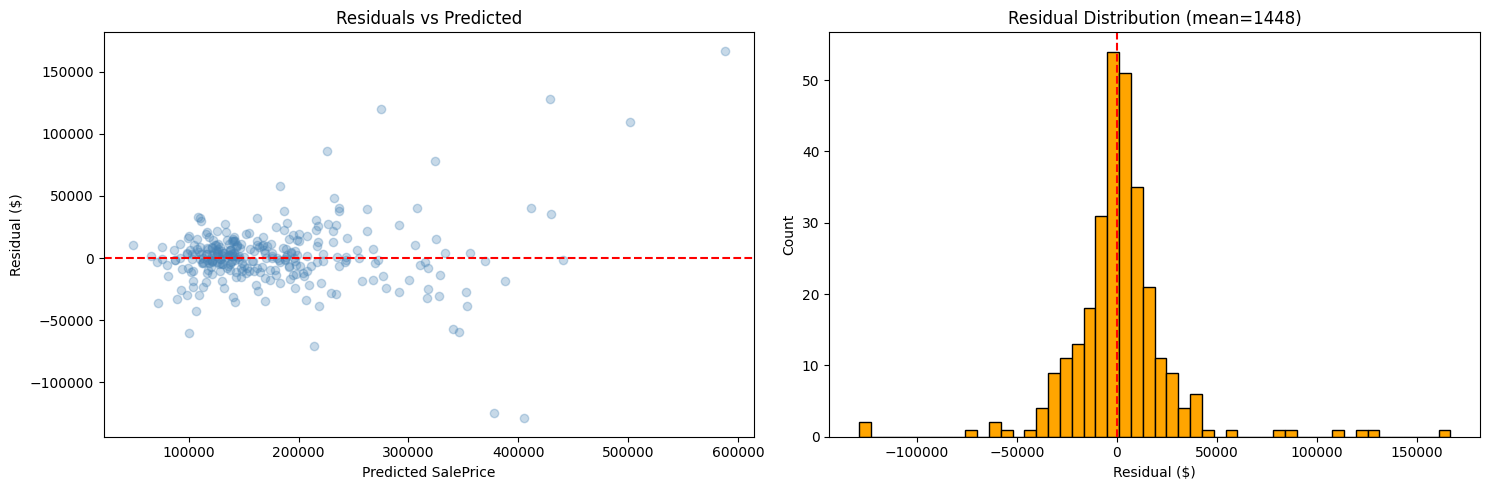

Mean residual:    $1,448
Std of residual:  $26,541
Max under-predict: $166,946
Max over-predict:  $-129,071


In [ ]:
# ============================================================
# CELL 13: Residual plots
# ============================================================
residuals = y_test_orig - y_pred

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15, 5))

# Residuals vs predicted
ax1.scatter(y_pred, residuals, alpha=0.3, color='steelblue')
ax1.axhline(0, color='red', linestyle='--')
ax1.set_xlabel('Predicted SalePrice')
ax1.set_ylabel('Residual ($)')
ax1.set_title('Residuals vs Predicted')

# Histogram of residuals
ax2.hist(residuals, bins=50, color='orange', edgecolor='black')
ax2.axvline(0, color='red', linestyle='--')
ax2.set_xlabel('Residual ($)')
ax2.set_ylabel('Count')
ax2.set_title(f'Residual Distribution (mean={residuals.mean():.0f})')

plt.tight_layout()
plt.show()

print(f"Mean residual:    ${residuals.mean():,.0f}")
print(f"Std of residual:  ${residuals.std():,.0f}")
print(f"Max under-predict: ${residuals.max():,.0f}")
print(f"Max over-predict:  ${residuals.min():,.0f}")

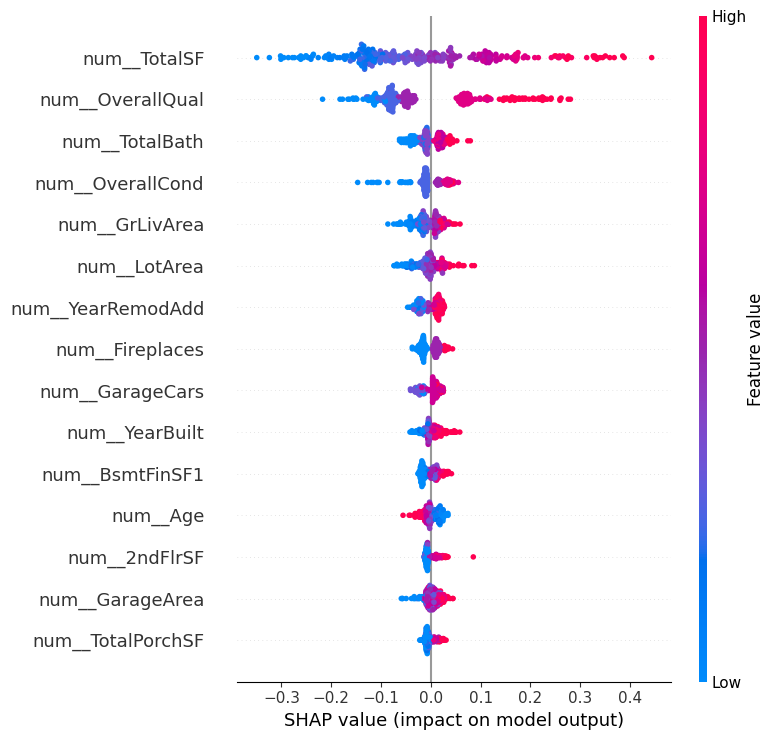

In [ ]:
# ============================================================
# CELL 14: SHAP feature importance (global)
# ============================================================
import shap

# Extract preprocessor and model from pipeline
preproc = best_xgb.named_steps['preprocessor']
model = best_xgb.named_steps['model']

# Transform X_test with fitted preprocessor
X_test_transformed = preproc.transform(X_test)
feature_names = preproc.get_feature_names_out()

# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

# Global importance plot
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=feature_names,
    max_display=15,
    show=True
)

Actual price:    $119,500
Predicted price: $116,625


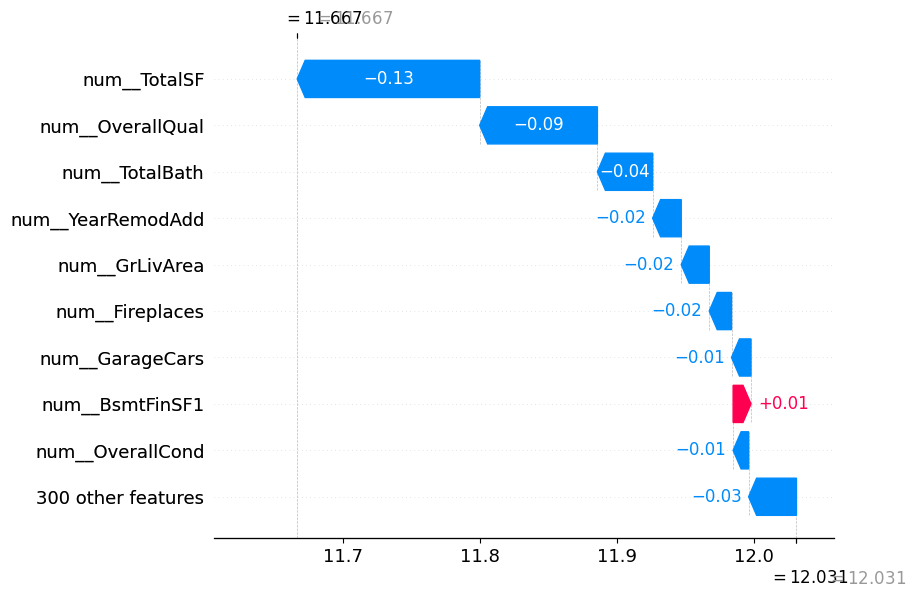

In [ ]:
# ============================================================
# CELL 15: SHAP — explain a single prediction
# ============================================================
# Pick a random test sample
idx = 42
print(f"Actual price:    ${y_test_orig.iloc[idx]:,.0f}")
print(f"Predicted price: ${y_pred[idx]:,.0f}")

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[idx],
    feature_names=feature_names
)

               name        MAE       RMSE     R2
      XGBoost + log 15517.7090 25950.1849 0.9122
 XGBoost (baseline) 15628.6299 26301.3113 0.9098
XGBoost tuned + log 15636.9365 26534.6469 0.9082
LightGBM (baseline) 16679.3108 28553.0421 0.8937
LightGBM (baseline) 16679.3108 28553.0421 0.8937


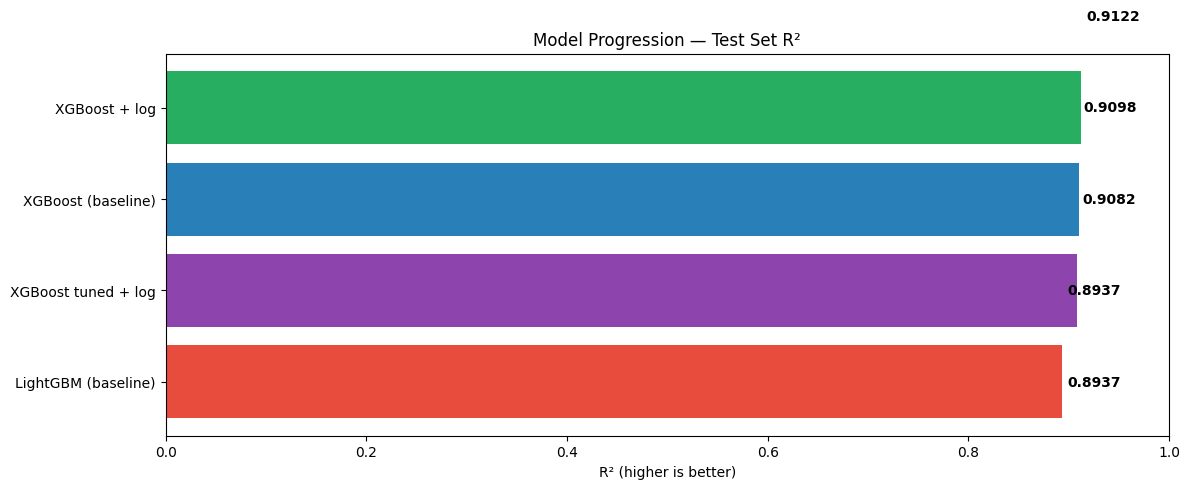

In [ ]:
# ============================================================
# CELL 16: Compare all models
# ============================================================
comparison = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'model'}
    for r in results
]).sort_values('R2', ascending=False).reset_index(drop=True)

print(comparison.round(4).to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#27ae60', '#2980b9', '#8e44ad', '#e74c3c', '#f39c12'][:len(comparison)]
ax.barh(comparison['name'][::-1], comparison['R2'][::-1], color=colors[::-1])
ax.set_xlabel('R² (higher is better)')
ax.set_title('Model Progression — Test Set R²')
ax.set_xlim(0, 1)
for i, v in enumerate(comparison['R2'][::-1]):
    ax.text(v + 0.005, i, f"{v:.4f}", va='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 17: Save the trained pipeline for deployment
# ============================================================
import joblib

joblib.dump(best_xgb, 'ames_xgb_model.pkl')
print("✅ Model saved as ames_xgb_model.pkl")

# Quick sanity check: reload and predict
loaded_model = joblib.load('ames_xgb_model.pkl')
sample = X_test.iloc[:1]
print(f"\nSample prediction: ${np.exp(loaded_model.predict(sample))[0]:,.0f}")

✅ Model saved as ames_xgb_model.pkl

Sample prediction: $143,835
